In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report

In [ ]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        # input to first hidden
        self.flatten = nn.Flatten()
        self.input_layer = nn.Linear(784, 16)

        # left branch
        self.left1 = nn.Linear(16, 8)
        self.left2 = nn.Linear(8, 8)

        # right branch
        self.right1 = nn.Linear(16, 12)
        self.right2 = nn.Linear(12, 8)

        # output
        self.output_layer = nn.Linear(16, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
      x = self.flatten(x)
      x = self.relu(self.input_layer(x))

      # left branch
      left1_out = self.relu(self.left1(x))
      left2_out = self.relu(self.left2(left1_out))

      # skip connection will add left1 output and left2 output
      skip = left1_out + left2_out

      # right branch
      right1_out = self.relu(self.right1(x))
      right2_out = self.relu(self.right2(right1_out))

      # concatenate skip result with right branch output
      combined = torch.cat([skip, right2_out], dim=1)

      # output
      out = self.output_layer(combined)
      return out

model = ANN()

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(), #takes image and converts to output tensor with all values in [0,1]
    transforms.Normalize((0.5,), (0.5,)) # new pixel value = (input-mean)/std deviation, and the mean and std deviation for the 3 colors R G B is given as two tuples with 3 values each. since this one is greyscale we give only first value of tuple. giving 0.5 for both will make it such that black pixels will have -1 value and white +1 value which increases backprop efficiency
])

train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.5MB/s]

Training samples: 60000
Test samples: 10000


In [ ]:
cost = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) #set adam model with learning rate 0.001

epochs = 10
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    # training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad() #reset gradients
        outputs = model(images)
        loss = cost(outputs, labels)
        loss.backward() #calculate gradients
        optimizer.step() #update

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc) #calculating accuracies and losses manually

    # validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = cost(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(test_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/10 | Train Loss: 0.6710 | Train Acc: 0.7602 | Val Loss: 0.5258 | Val Acc: 0.8098
Epoch 2/10 | Train Loss: 0.4522 | Train Acc: 0.8381 | Val Loss: 0.4643 | Val Acc: 0.8328
Epoch 3/10 | Train Loss: 0.4128 | Train Acc: 0.8526 | Val Loss: 0.4399 | Val Acc: 0.8471
Epoch 4/10 | Train Loss: 0.3918 | Train Acc: 0.8593 | Val Loss: 0.4298 | Val Acc: 0.8488
Epoch 5/10 | Train Loss: 0.3808 | Train Acc: 0.8626 | Val Loss: 0.4369 | Val Acc: 0.8427
Epoch 6/10 | Train Loss: 0.3682 | Train Acc: 0.8675 | Val Loss: 0.4040 | Val Acc: 0.8586
Epoch 7/10 | Train Loss: 0.3582 | Train Acc: 0.8713 | Val Loss: 0.4091 | Val Acc: 0.8535
Epoch 8/10 | Train Loss: 0.3536 | Train Acc: 0.8720 | Val Loss: 0.4055 | Val Acc: 0.8540
Epoch 9/10 | Train Loss: 0.3462 | Train Acc: 0.8740 | Val Loss: 0.4040 | Val Acc: 0.8551
Epoch 10/10 | Train Loss: 0.3418 | Train Acc: 0.8758 | Val Loss: 0.3897 | Val Acc: 0.8610


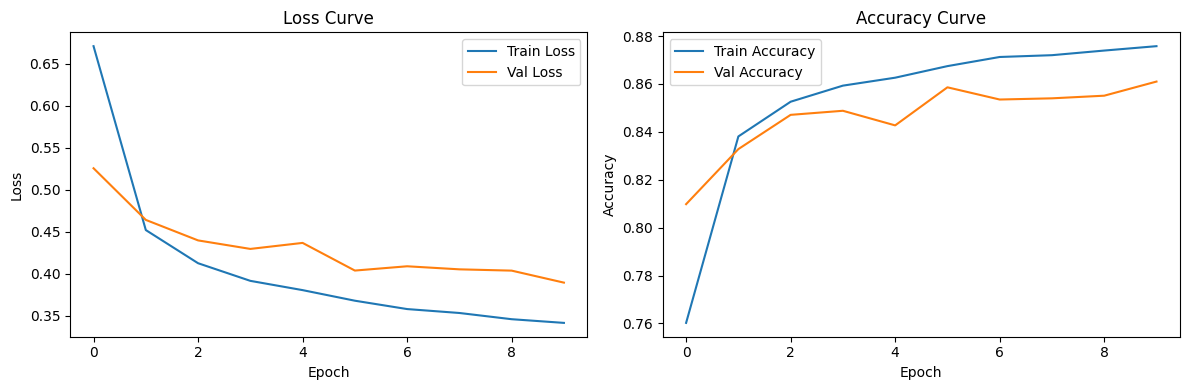

In [ ]:
plt.figure(figsize=(12, 4))

# loss curve
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# accuracy curve
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import pickle

with open('model_weights.pkl', 'wb') as f:
    pickle.dump(model.state_dict(), f)

print("Model weights saved successfully")

Model weights saved successfully


In [ ]:
model.eval()
predictions = []
image_ids = []
idx = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for pred in predicted:
            predictions.append(pred.item())
            image_ids.append(idx)
            idx += 1

submission = pd.DataFrame({
    'ImageId': image_ids,
    'Label': predictions
})

submission.to_csv('submission.csv', index=False)
print("Saved to csv successfully")

Saved to csv successfully
